In [17]:
#Import Libraries

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
)

In [18]:
#Load the dataset
df = pd.read_csv("week3/major-cities-in-pakistan-by-population.csv")

df.head()

,Rank,City,Population 2017 Census,Population 1998 Census,Change,Province
0,1,Karachi,14916456,9339023,0.5972,Sindh
1,2,Lahore,11126285,5209088,1.1359,Punjab
2,3,Faisalabad,3204726,2008861,0.5953,Punjab
3,4,Rawalpindi,2098231,1409768,0.4884,Punjab
4,5,Gujranwala,2027001,1132509,0.7898,Punjab


In [29]:
#Preparing Features Predict City Population Using Multiple Features 

#province_dummies = pd.get_dummies(df["Province"], drop_first=True)
province_dummies = pd.get_dummies(df["Province"], drop_first=True, dtype=int)

# Create the feature matrix
X = pd.concat(
    [df[["Population 1998 Census", "Change"]], province_dummies],
    axis=1
)

# Target variable
y = df["Population 2017 Census"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

X.head()

Feature matrix shape: (100, 7)
Target shape: (100,)


,Population 1998 Census,Change,Balochistan,Islamabad,Khyber Pakhtunkhwa,Punjab,Sindh
0,9339023,0.5972,0,0,0,0,1
1,5209088,1.1359,0,0,0,1,0
2,2008861,0.5953,0,0,0,1,0
3,1409768,0.4884,0,0,0,1,0
4,1132509,0.7898,0,0,0,1,0


Matplotlib is building the font cache; this may take a moment.


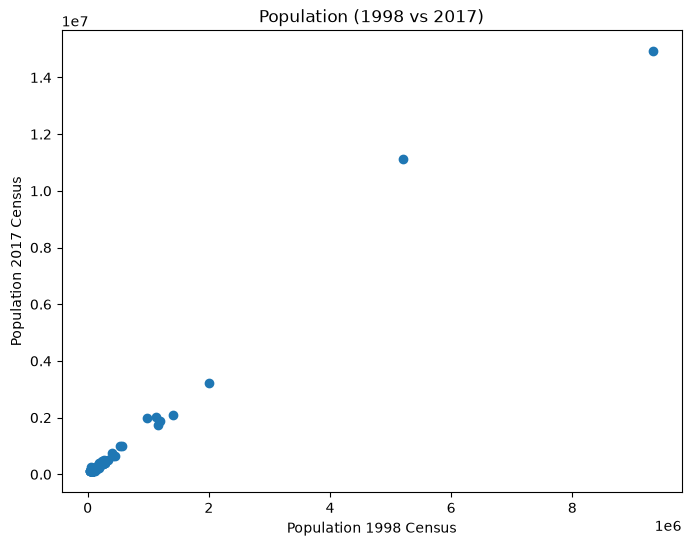

In [30]:
#GRAPH(Actual vs Predicted Population)
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    df["Population 1998 Census"],
    df["Population 2017 Census"]
)

plt.title("Population (1998 vs 2017)")
plt.xlabel("Population 1998 Census")
plt.ylabel("Population 2017 Census")

plt.show()

In [20]:
# Split the dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (80, 7)
Testing set shape: (20, 7)


In [21]:
# Create and train the multiple linear regression model
model = LinearRegression()

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [22]:
# Predict the population for the test data
y_pred = model.predict(X_test)

print("First 5 Predictions:")
print(y_pred[:5])

First 5 Predictions:
[ 71180.25698797 164538.86039078 101768.51501139 181484.10011713
 235770.77133155]


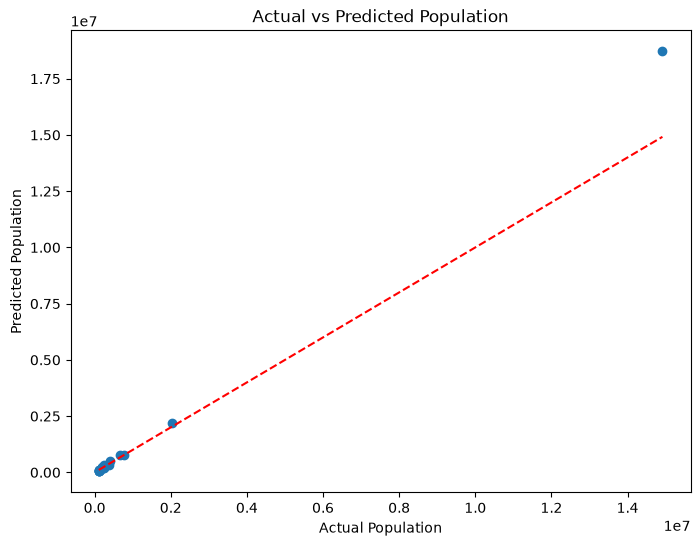

In [31]:
#GRAPH 2(Population 1998 vs Population 2017)
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--"
)

plt.title("Actual vs Predicted Population")
plt.xlabel("Actual Population")
plt.ylabel("Predicted Population")

plt.show()

In [23]:
# Evaluate the model
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R² Score: {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

R² Score: 0.9294
Mean Absolute Error (MAE): 240947.81
Root Mean Squared Error (RMSE): 851078.15


In [24]:
# Simple Linear Regression (using only Population 1998 Census)

X_simple = df[["Population 1998 Census"]]
y = df["Population 2017 Census"]

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple,
    y,
    test_size=0.2,
    random_state=42
)

simple_model = LinearRegression()
simple_model.fit(X_train_s, y_train_s)

y_pred_simple = simple_model.predict(X_test_s)

print("Simple Model Performance")
print(f"R² Score: {r2_score(y_test_s, y_pred_simple):.4f}")
print(f"MAE: {mean_absolute_error(y_test_s, y_pred_simple):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_s, y_pred_simple)):.2f}")

Simple Model Performance
R² Score: 0.9294
MAE: 240947.81
RMSE: 851078.15


In [25]:
print("Simple model R²:", simple_model.score(X_test_s, y_test_s))
print("Multiple model R²:", model.score(X_test, y_test))

print("\nSimple coefficient:")
print(simple_model.coef_)

print("\nMultiple coefficients:")
for feature, coef in zip(X.columns, model.coef_):
    print(f"{feature}: {coef}")

Simple model R²: 0.9294355951608667
Multiple model R²: 0.9294355951608846

Simple coefficient:
[2.00987305]

Multiple coefficients:
Population 1998 Census: 2.0098730549578443
Change: -5.039804033206107e-08
Balochistan: -1.800509329812172e-08
Islamabad: 1.566672540136758e-08
Khyber Pakhtunkhwa: -5.289617795326688e-08
Punjab: 1.993706538393107e-07
Sindh: -1.234392296103849e-07


In [26]:
# Display each feature with its coefficient
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients

,Feature,Coefficient
0,Population 1998 Census,2.009873e+00
1,Change,-5.039804e-08
2,Balochistan,-1.800509e-08
3,Islamabad,1.566673e-08
4,Khyber Pakhtunkhwa,-5.289618e-08
5,Punjab,1.993707e-07
6,Sindh,-1.234392e-07


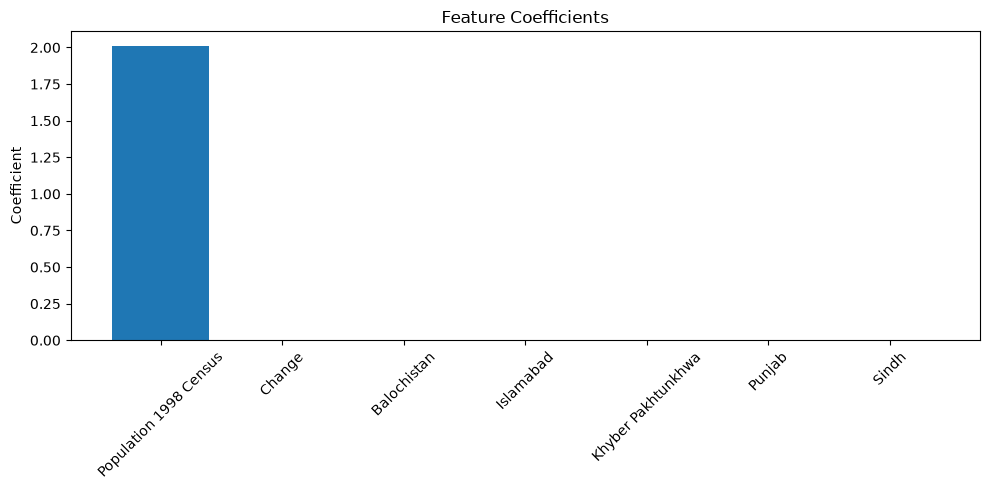

In [33]:
#GRAPH 3(Feature Importance (Coefficients))
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

plt.figure(figsize=(10, 5))

plt.bar(coefficients["Feature"], coefficients["Coefficient"])

plt.xticks(rotation=45)

plt.title("Feature Coefficients")
plt.ylabel("Coefficient")

plt.tight_layout()
plt.show()

In [27]:
# Display Lahore's data
df[df["City"] == "Lahore"]

,Rank,City,Population 2017 Census,Population 1998 Census,Change,Province
1,2,Lahore,11126285,5209088,1.1359,Punjab


In [28]:
# Manually create Lahore's feature row
lahore_features = pd.DataFrame({
    "Population 1998 Census": [5209088],
    "Change": [1.1359],
    "Balochistan": [0],
    "Islamabad": [0],
    "Khyber Pakhtunkhwa": [0],
    "Punjab": [1],
    "Sindh": [0]
})

# Predict Lahore's 2017 population
predicted_population = model.predict(lahore_features)[0]

# Actual population
actual_population = 11126285

print(f"Predicted Population: {predicted_population:.0f}")
print(f"Actual Population: {actual_population}")
print(f"Difference: {abs(predicted_population - actual_population):.0f}")

Predicted Population: 10409137
Actual Population: 11126285
Difference: 717148


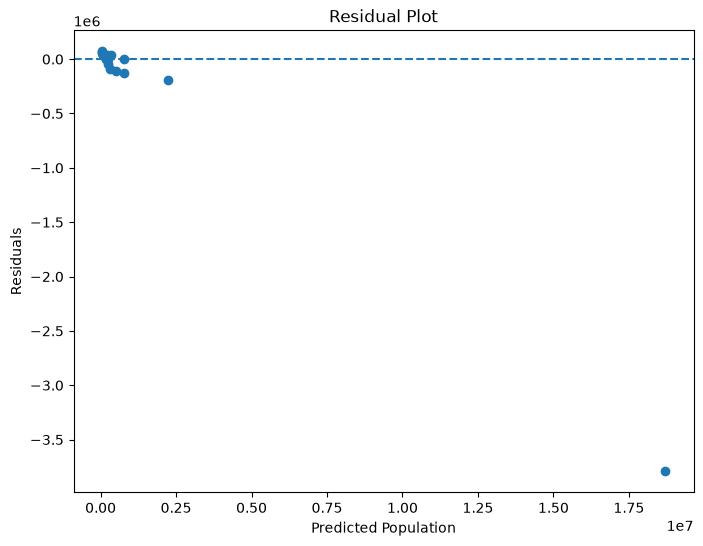

In [34]:
# Residual Plot
residuals = y_test - y_pred

plt.figure(figsize=(8, 6))

plt.scatter(y_pred, residuals)

plt.axhline(y=0, linestyle="--")

plt.title("Residual Plot")
plt.xlabel("Predicted Population")
plt.ylabel("Residuals")

plt.show()